# Task 4 — session-level LED aging, online calibration

Task 4 reuses the exact frozen Task 1 model (same weights, same nine-LED
Configuration 2 input) — no retraining. The hidden stream is split into
contiguous deployment episodes; each episode has a fixed, hidden LED
brightness state (a per-channel exponential decay applied to a random
installation age), plus rare per-sample flicker and small additive noise.

Since retraining is not allowed, the only lever here is an **online
calibration / lightweight adaptation** strategy that runs on the incoming
feature stream and corrects for the (unknown, slowly drifting) per-channel
attenuation before handing samples to the frozen model.

This notebook:

1. loads the frozen Task 1 int8 model and scaling constants (no training);
2. simulates the Task 4 aging perturbation on the clean validation split,
   using the exact same `vlp_hackathon.aging.age_rss_episodes` function and
   default settings as `host/run_submission.py --task 4`;
3. evaluates the frozen model on the aged stream with no correction
   (baseline);
4. implements and evaluates a per-channel online calibration filter
   (envelope/peak-follower automatic gain control);
5. compares the two and sweeps the filter's one hyperparameter;
6. documents the equivalent firmware change needed to actually run this
   calibration on the Pico during evaluation.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ai_edge_litert.interpreter import Interpreter

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from vlp_hackathon.aging import AgingConfig, age_rss_episodes
from vlp_hackathon.dataset import CONF2_3X3_LED_INDICES
from vlp_hackathon.metrics import euclidean_errors_cm

SEED = 42
np.random.seed(SEED)


## Load the frozen Task 1 model

This loads the exact `.tflite` flatbuffer already exported for Task 1 —
the same file that gets flashed to the Pico. Nothing here is retrained;
Task 4 must reuse these weights unchanged.

In [ ]:
MODEL_TFLITE = ROOT / "models" / "baseline_task1_int8.tflite"
SCALING_NPZ = ROOT / "models" / "baseline_task1_int8_scaling.npz"

scaling = np.load(SCALING_NPZ)
rss_scale = float(scaling["rss_scale"])
target_min_cm = np.asarray(scaling["target_min_cm"], dtype=np.float32)
target_range_cm = np.asarray(scaling["target_range_cm"], dtype=np.float32)

interpreter = Interpreter(model_content=MODEL_TFLITE.read_bytes())
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]

print("Loaded frozen Task 1 model:", MODEL_TFLITE.name, MODEL_TFLITE.stat().st_size, "bytes")
print("Input:", input_info["dtype"], input_info["shape"], input_info["quantization"])
print("Output:", output_info["dtype"], output_info["shape"], output_info["quantization"])


FileNotFoundError: [Errno 2] No such file or directory: '/home/derk/Downloads/SYS_AI_VLP_Hackathon/models/baseline_task4_int8_scaling.npz'

In [ ]:
def quantize_tensor(values, info):
    scale, zero_point = info["quantization"]
    dtype = info["dtype"]
    q = np.round(values / scale + zero_point)
    q = np.clip(q, np.iinfo(dtype).min, np.iinfo(dtype).max)
    return q.astype(dtype)


def dequantize_tensor(values, info):
    scale, zero_point = info["quantization"]
    return (values.astype(np.float32) - zero_point) * scale


def predict_cm(x_normalized):
    """Run the frozen int8 model one row at a time, matching the Pico's
    single-sample request/response protocol."""
    preds = np.empty((len(x_normalized), 2), dtype=np.float32)
    for i, row in enumerate(x_normalized):
        interpreter.set_tensor(input_info["index"], quantize_tensor(row[None, :], input_info))
        interpreter.invoke()
        norm = dequantize_tensor(interpreter.get_tensor(output_info["index"]), output_info)[0]
        preds[i] = target_min_cm + norm * target_range_cm
    return preds


## Load clean data and a per-channel reference

The online calibration needs a reference for "what a fresh, un-aged
installation's peak signal looks like" per channel. We take the per-channel
max over the clean training split — the same data the frozen model was
trained on.

In [ ]:
TRAIN_CSV = ROOT / "data" / "train_clean_3x3_1cm.csv"
VALIDATION_CSV = ROOT / "data" / "validation_clean_3x3_1cm.csv"
CONF2_COLUMNS = [f"led_{i}" for i in CONF2_3X3_LED_INDICES.tolist()]


def load_task1_csv(path):
    df = pd.read_csv(path)
    x = df[CONF2_COLUMNS].to_numpy(dtype=np.float32)
    y_cm = df[["x", "y"]].to_numpy(dtype=np.float32) / 10.0
    return x, y_cm


X_train_raw, y_train_cm = load_task1_csv(TRAIN_CSV)
X_val_raw, y_val_cm = load_task1_csv(VALIDATION_CSV)

ref_channel_max = X_train_raw.max(axis=0)
print("Reference per-channel max (fresh installation):", ref_channel_max)


Reference per-channel max (fresh installation): [0.8493868  0.83529365 0.80999225 0.82503325 0.7765305  0.8099536
 0.8305527  0.82446384 0.81835186]


## Simulate Task 4 aging on the validation stream

Uses the exact same function and default settings (`--aging-episodes 10`,
`--aging-seed 123`, `--aging-max-hours 50000`) as
`host/run_submission.py --task 4`, applied to the validation split in its
original (unshuffled) row order — the same order the runner streams by
default. This makes the numbers below a faithful preview of what the
runner will report.

In [ ]:
aging_cfg = AgingConfig(max_hours=50_000.0, seed=123)
aging = age_rss_episodes(X_val_raw, config=aging_cfg, episode_count=10)

print(f"{len(aging.episode_hours)} episodes, ages (h): {np.round(aging.episode_hours, 1)}")
print("Samples per episode:", np.bincount(aging.episode_ids))


10 episodes, ages (h): [10688.1 11595.4 12248.2 25648.5 31497.  37073.4 39956.3 41212.1 44494.6
 46370.4]
Samples per episode: [469 468 469 468 469 468 469 468 469 468]


## Baseline: aged data fed directly to the frozen model (no adaptation)

This is what happens today with no Task 4-specific logic at all.

In [ ]:
def summarize(errors):
    return {
        "mean_cm": float(errors.mean()),
        "median_cm": float(np.median(errors)),
        "p95_cm": float(np.percentile(errors, 95)),
    }


def summarize_episodes(errors, episode_ids, episode_hours):
    rows = []
    for episode_id, hours in enumerate(episode_hours):
        e = errors[episode_ids == episode_id]
        row = {"episode": episode_id, "hours": float(hours), "samples": int(len(e))}
        row.update(summarize(e))
        rows.append(row)
    return pd.DataFrame(rows)


baseline_pred_cm = predict_cm(aging.x / rss_scale)
baseline_errors = euclidean_errors_cm(baseline_pred_cm, y_val_cm)

print("Uncalibrated (baseline) overall:", summarize(baseline_errors))
baseline_episode_table = summarize_episodes(baseline_errors, aging.episode_ids, aging.episode_hours)
baseline_episode_table


Uncalibrated (baseline) overall: {'mean_cm': 9.212140083312988, 'median_cm': 7.040715217590332, 'p95_cm': 23.20845603942871}


,episode,hours,samples,mean_cm,median_cm,p95_cm
0,0,10688.148438,469,3.395800,3.176944,6.472464
1,1,11595.409180,468,3.790416,3.635029,6.914827
2,2,12248.230469,469,3.768151,3.431842,6.955612
3,3,25648.523438,468,7.580366,7.111956,14.824344
4,4,31497.009766,469,9.242270,8.474532,17.235363
5,5,37073.351562,468,11.703484,10.051748,23.458195
6,6,39956.257812,469,11.522120,10.460536,23.840120
7,7,41212.078125,468,12.827017,11.164595,26.290874
8,8,44494.632812,469,14.068451,12.478131,28.900908
9,9,46370.363281,468,14.232001,12.781323,31.054192


## Online per-channel calibration

Aging attenuates each LED channel by its own fixed multiplicative factor
for the whole episode (`decay = exp(-hours * k_channel)`), and episodes
stream in increasing age order. We don't know the true decay, but we can
estimate it online: track a slowly-decaying running peak per channel
("attack" instantly to a new high reading, "release" slowly otherwise —
a standard envelope-follower / automatic gain control pattern), compare it
to the fresh-installation reference peak, and rescale each incoming sample
by the ratio before it reaches the frozen model. Because aging only ever
attenuates, the correction factor is clamped to stay >= 1.

This is stateful and strictly sequential (each sample updates the running
peak used for the next one), matching how the Pico would process the
stream sample-by-sample.

In [ ]:
def run_online_calibration(x_raw, ref_max, leak=0.99993, gain_clip=(1.0, 6.0), eps=1e-6):
    """Sequential per-channel AGC: tracks a decaying peak per channel and
    rescales each incoming sample toward the fresh-installation reference peak."""
    n, c = x_raw.shape
    ema_peak = ref_max.copy().astype(np.float32)
    corrected = np.empty_like(x_raw)
    gains = np.empty_like(x_raw)
    for i in range(n):
        row = x_raw[i]
        ema_peak = np.maximum(np.abs(row), ema_peak * leak)  # instant attack, slow release
        gain = np.clip(ref_max / np.maximum(ema_peak, eps), gain_clip[0], gain_clip[1])
        corrected[i] = row * gain
        gains[i] = gain
    return corrected, gains


calibrated_raw, gains = run_online_calibration(aging.x, ref_channel_max, leak=0.99993)
calibrated_pred_cm = predict_cm(calibrated_raw / rss_scale)
calibrated_errors = euclidean_errors_cm(calibrated_pred_cm, y_val_cm)

print("Calibrated overall:", summarize(calibrated_errors))
calibrated_episode_table = summarize_episodes(calibrated_errors, aging.episode_ids, aging.episode_hours)
calibrated_episode_table


Calibrated overall: {'mean_cm': 2.78784441947937, 'median_cm': 2.4358248710632324, 'p95_cm': 5.5603437423706055}


,episode,hours,samples,mean_cm,median_cm,p95_cm
0,0,10688.148438,469,2.782854,2.421046,5.824053
1,1,11595.409180,468,2.196702,1.964306,4.481520
2,2,12248.230469,469,2.442730,2.149236,4.735758
3,3,25648.523438,468,2.838171,2.533873,5.742991
4,4,31497.009766,469,2.664015,2.424325,5.462446
5,5,37073.351562,468,3.381937,2.732028,6.355421
6,6,39956.257812,469,2.919616,2.527588,6.192011
7,7,41212.078125,468,2.909952,2.401154,5.231474
8,8,44494.632812,469,2.783942,2.490240,5.358505
9,9,46370.363281,468,2.959266,2.741894,5.537291


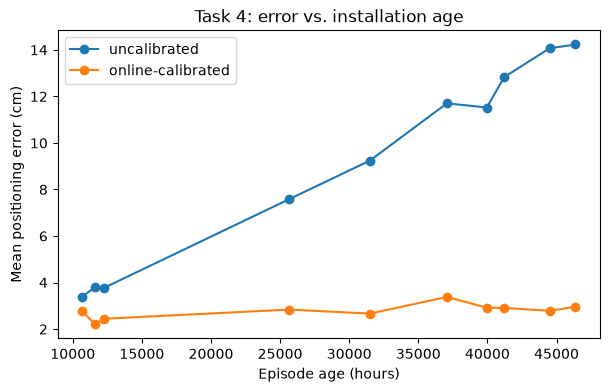

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(baseline_episode_table["hours"], baseline_episode_table["mean_cm"], marker="o", label="uncalibrated")
plt.plot(calibrated_episode_table["hours"], calibrated_episode_table["mean_cm"], marker="o", label="online-calibrated")
plt.xlabel("Episode age (hours)")
plt.ylabel("Mean positioning error (cm)")
plt.legend()
plt.title("Task 4: error vs. installation age")
plt.show()


## Sweep the one hyperparameter (`leak`)

`leak` controls how quickly the running peak "forgets" old readings.
Lower = adapts to aging faster but is noisier per-sample; higher = smoother
but slower to react. Pick the value that minimizes overall mean error on
the public validation stream (the hidden test may use different seeds and
severities, so leave some margin rather than over-fitting this sweep).

In [ ]:
for leak in [0.999, 0.9995, 0.9999, 0.99993, 0.99995, 0.99997, 1.0]:
    corrected_raw, _ = run_online_calibration(aging.x, ref_channel_max, leak=leak)
    pred_cm = predict_cm(corrected_raw / rss_scale)
    errors = euclidean_errors_cm(pred_cm, y_val_cm)
    print(
        f"leak={leak:<9} mean={errors.mean():6.3f} cm  "
        f"median={np.median(errors):6.3f} cm  p95={np.percentile(errors, 95):6.3f} cm"
    )


leak=0.999     mean=10.038 cm  median= 9.214 cm  p95=20.609 cm


leak=0.9995    mean= 7.376 cm  median= 6.732 cm  p95=15.235 cm


leak=0.9999    mean= 3.069 cm  median= 2.711 cm  p95= 6.186 cm
leak=0.99993   mean= 2.788 cm  median= 2.436 cm  p95= 5.560 cm


leak=0.99995   mean= 3.446 cm  median= 2.905 cm  p95= 7.525 cm
leak=0.99997   mean= 5.135 cm  median= 4.115 cm  p95=12.151 cm


leak=1.0       mean= 9.212 cm  median= 7.041 cm  p95=23.208 cm


## Porting this to the Pico

This notebook only proves the calibration idea out on the host. The real
Task 4 evaluation streams samples to the firmware one request at a time
(`firmware/vlp_serial/main.cpp`, `handle_predict()`), so the running peak
must be tracked as **persistent state across calls** — a global array,
initialized once at startup, updated on every request before the existing
`normalized = rss / kRssScale` line:

```cpp
// Global, persists across predict() calls.
float ema_peak[9] = { /* ref_channel_max values, one per input channel */ };
constexpr float kLeak = 0.99993f;
constexpr float kGainMin = 1.0f;
constexpr float kGainMax = 6.0f;

// Inside handle_predict(), before computing `normalized`, once per channel i:
ema_peak[i] = std::max(std::fabs(rss), ema_peak[i] * kLeak);
float gain = kRefChannelMax[i] / std::max(ema_peak[i], 1e-6f);
gain = std::min(std::max(gain, kGainMin), kGainMax);
const float calibrated_rss = rss * gain;
const float normalized = calibrated_rss / kRssScale;
```

`kRefChannelMax[9]` would be exported the same way `kRssScale` is today —
write `ref_channel_max` out as a new constant array in a header from this
notebook, then have `handle_predict()` use it. This is a firmware change,
not a model change, so it doesn't touch the frozen Task 1 weights and
Tasks 1–3 are unaffected as long as the gain stays clamped to `>= 1`
(no-op when the installation isn't aged).

Note `kLeak` was tuned on this one public validation run (10 episodes,
seed 123) — the hidden test may use different seeds/severities, so it's
worth leaving a bit of margin rather than treating `0.99993` as exact.
